In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
BASE_DIR = Path(r"C:\Users\LENOVO\Desktop\nifty100_project")

CLEAN_DIR = BASE_DIR / "data" / "clean"

CLEAN_DIR

WindowsPath('C:/Users/LENOVO/Desktop/nifty100_project/data/clean')

In [3]:
# Load Clean Files
companies = pd.read_csv(CLEAN_DIR / "companies_clean.csv")
profit = pd.read_csv(CLEAN_DIR / "profit_clean.csv")
balance = pd.read_csv(CLEAN_DIR / "balancesheet_clean.csv")
cashflow = pd.read_csv(CLEAN_DIR / "cashflow_clean.csv")
analysis = pd.read_csv(CLEAN_DIR / "analysis_clean.csv")

print("companies:", companies.shape)
print("profit:", profit.shape)
print("balance:", balance.shape)
print("cashflow:", cashflow.shape)
print("analysis:", analysis.shape)

companies: (92, 14)
profit: (1119, 13)
balance: (1312, 15)
cashflow: (1185, 9)
analysis: (20, 6)


In [4]:
profit.head()

,symbol,year,fiscal_year,sales,expenses,operating_profit,opm_percentage,net_profit,eps,dividend_payout,net_profit_margin_pct,expense_ratio_pct,interest_coverage
0,ABB,Mar 2014,2014,2276,2009,267.0,12.0,198,93.0,25.0,8.699473,88.268893,NaN
1,ABB,Mar 2015,2015,2289,1977,312.0,14.0,229,108.0,29.0,10.004369,86.369594,NaN
2,ABB,Mar 2016,2016,2614,2250,365.0,14.0,255,120.0,29.0,9.755164,86.074981,121.666667
3,ABB,Mar 2017,2017,2903,2505,398.0,14.0,277,130.0,31.0,9.541853,86.290045,199.000000
4,ABB,Mar 2018,2018,3298,2774,525.0,16.0,401,189.0,29.0,12.158884,84.111583,131.250000


In [5]:
# Latest Fiscal Year
latest_year = profit['fiscal_year'].max()

latest_year

np.int64(2024)

In [6]:
# Latest Year Profit Data
latest_profit = profit[profit['fiscal_year'] == latest_year].copy()

latest_profit.shape

(99, 13)

In [7]:
# Company Names Join
latest_profit = latest_profit.merge(
    companies[['symbol', 'company_name']],
    on='symbol',
    how='left'
)

latest_profit.head()

,symbol,year,fiscal_year,sales,expenses,operating_profit,opm_percentage,net_profit,eps,dividend_payout,net_profit_margin_pct,expense_ratio_pct,interest_coverage,company_name
0,ABB,Mar 2024,2024,5849,4396,1453.0,25.0,1201,565.0,73.0,20.533425,75.158147,121.083333,Abbott India Ltd
1,ADANIENSOL,Mar 2024,2024,16607,10896,5711.0,30.0,1196,10.0,0.0,7.201782,65.610887,2.063968,Adani Energy Solutions Ltd
2,ADANIENT,Mar 2024,2024,96421,85044,11377.0,12.0,3335,28.0,5.0,3.458790,88.200703,2.497695,Adani Enterprises Ltd
3,ADANIGREEN,Mar 2024,2024,9220,1902,7318.0,79.0,1260,7.0,0.0,13.665944,20.629067,1.461846,Adani Green Energy Ltd
4,ADANIPORTS,Mar 2024,2024,26711,11121,15589.0,58.0,8104,38.0,16.0,30.339560,41.634533,5.703988,Adani Ports & Special Economic Zone Ltd


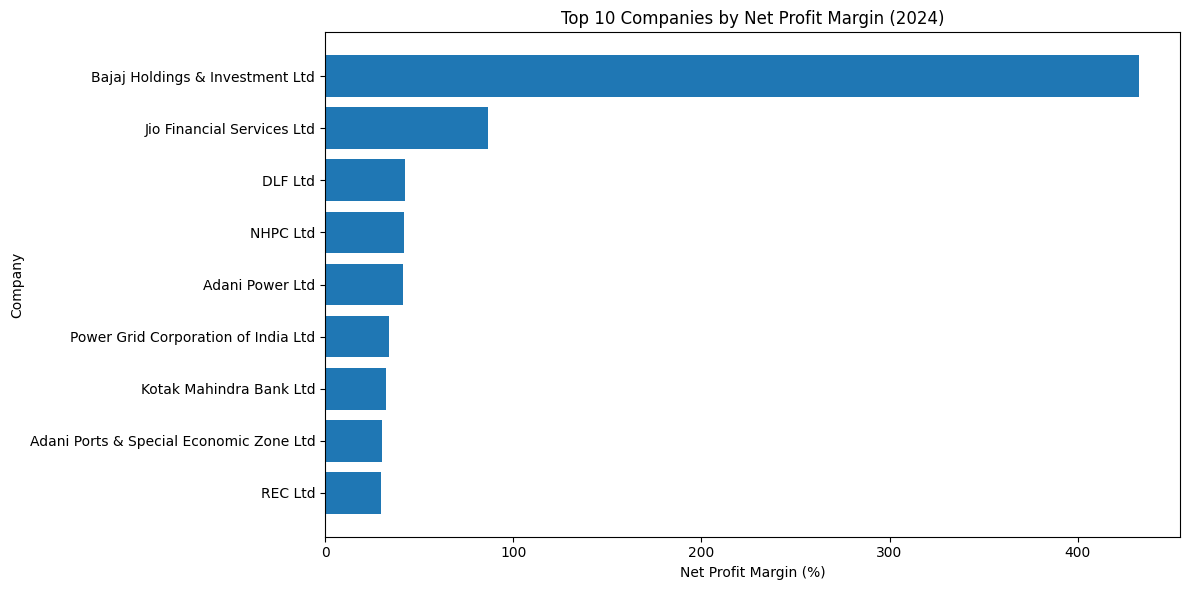

In [8]:
# Top 10 Companies by Net Profit Margin Chart
top_margin = latest_profit.sort_values(
    by='net_profit_margin_pct',
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_margin['company_name'], top_margin['net_profit_margin_pct'])
plt.xlabel("Net Profit Margin (%)")
plt.ylabel("Company")
plt.title(f"Top 10 Companies by Net Profit Margin ({latest_year})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
# Cross Check Top Margin Table
top_margin[['company_name', 'sales', 'net_profit', 'net_profit_margin_pct']]

,company_name,sales,net_profit,net_profit_margin_pct
14,Bajaj Holdings & Investment Ltd,1702,7365,432.726204
54,Jio Financial Services Ltd,1855,1605,86.522911
29,DLF Ltd,6427,2724,42.383694
67,NHPC Ltd,9632,4028,41.818937
6,Adani Power Ltd,50351,20829,41.367599
73,Power Grid Corporation of India Ltd,45843,15573,33.970290
57,Kotak Mahindra Bank Ltd,56237,18213,32.386151
4,Adani Ports & Special Economic Zone Ltd,26711,8104,30.339560
5,Adani Ports & Special Economic Zone Ltd,26711,8104,30.339560
74,REC Ltd,47517,14145,29.768293


In [10]:
# Duplicate Check
latest_profit[latest_profit.duplicated(subset=['symbol'], keep=False)][
    ['symbol', 'company_name', 'fiscal_year', 'sales', 'net_profit']
].sort_values('symbol')

,symbol,company_name,fiscal_year,sales,net_profit
4,ADANIPORTS,Adani Ports & Special Economic Zone Ltd,2024,26711,8104
5,ADANIPORTS,Adani Ports & Special Economic Zone Ltd,2024,26711,8104


In [11]:
# Remove Duplicate Company-Year Rows
latest_profit = latest_profit.drop_duplicates(
    subset=['symbol', 'fiscal_year'],
    keep='first'
).reset_index(drop=True)

latest_profit.shape

(98, 14)

In [12]:
# Recreate Top Margin Chart Data
top_margin = latest_profit.sort_values(
    by='net_profit_margin_pct',
    ascending=False
).head(10)

top_margin[['company_name', 'sales', 'net_profit', 'net_profit_margin_pct']]

,company_name,sales,net_profit,net_profit_margin_pct
13,Bajaj Holdings & Investment Ltd,1702,7365,432.726204
53,Jio Financial Services Ltd,1855,1605,86.522911
28,DLF Ltd,6427,2724,42.383694
66,NHPC Ltd,9632,4028,41.818937
5,Adani Power Ltd,50351,20829,41.367599
72,Power Grid Corporation of India Ltd,45843,15573,33.970290
56,Kotak Mahindra Bank Ltd,56237,18213,32.386151
4,Adani Ports & Special Economic Zone Ltd,26711,8104,30.339560
73,REC Ltd,47517,14145,29.768293
51,ITC Ltd,70866,20751,29.282025


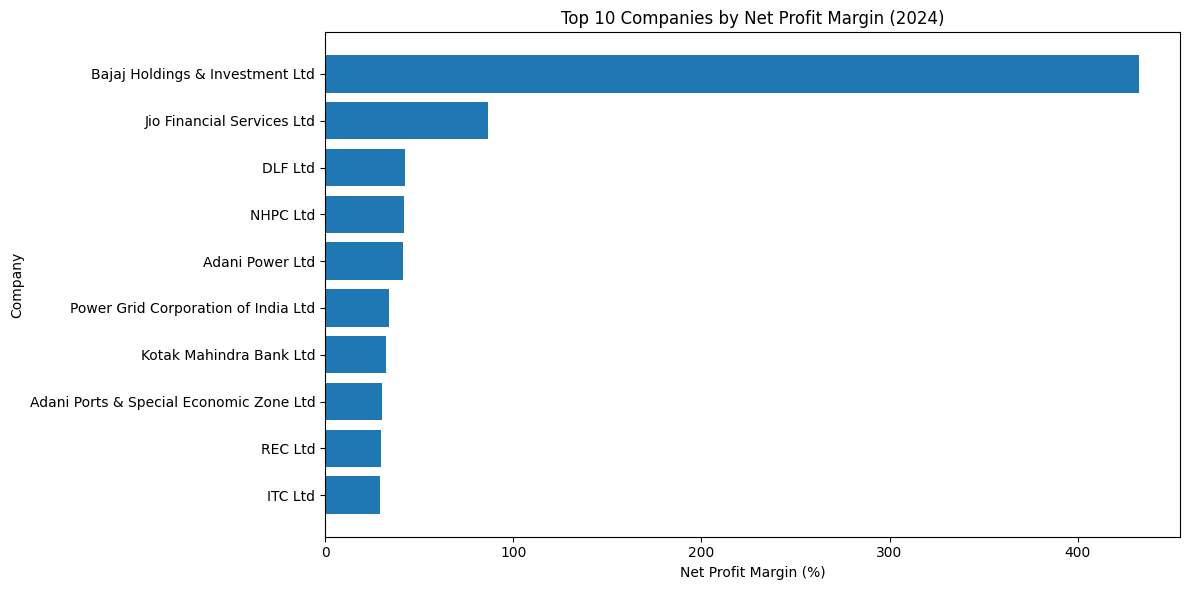

In [13]:
# Again Top 10 Companies by Net Profit Margin Chart
top_margin = latest_profit.sort_values(
    by='net_profit_margin_pct',
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_margin['company_name'], top_margin['net_profit_margin_pct'])
plt.xlabel("Net Profit Margin (%)")
plt.ylabel("Company")
plt.title(f"Top 10 Companies by Net Profit Margin ({latest_year})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<h2> Nifty100_health_score_features </h2>

In [14]:
# Latest Balance & Cashflow
latest_balance = balance[balance['fiscal_year'] == latest_year].copy()
latest_cashflow = cashflow[cashflow['fiscal_year'] == latest_year].copy()

latest_balance = latest_balance.drop_duplicates(subset=['symbol', 'fiscal_year'], keep='first')
latest_cashflow = latest_cashflow.drop_duplicates(subset=['symbol', 'fiscal_year'], keep='first')

print("latest_profit:", latest_profit.shape)
print("latest_balance:", latest_balance.shape)
print("latest_cashflow:", latest_cashflow.shape)

latest_profit: (98, 14)
latest_balance: (98, 15)
latest_cashflow: (99, 9)


In [15]:
# Scoring Base Dataset
score_df = latest_profit.merge(
    latest_balance[['symbol', 'debt_to_equity', 'total_assets']],
    on='symbol',
    how='left'
).merge(
    latest_cashflow[['symbol', 'free_cash_flow']],
    on='symbol',
    how='left'
)

score_df = score_df[[
    'symbol',
    'company_name',
    'fiscal_year',
    'net_profit_margin_pct',
    'expense_ratio_pct',
    'debt_to_equity',
    'free_cash_flow',
    'net_profit'
]]

score_df.head()

,symbol,company_name,fiscal_year,net_profit_margin_pct,expense_ratio_pct,debt_to_equity,free_cash_flow,net_profit
0,ABB,Abbott India Ltd,2024,20.533425,75.158147,0.022438,797.0,1201
1,ADANIENSOL,Adani Energy Solutions Ltd,2024,7.201782,65.610887,2.932521,1095.0,1196
2,ADANIENT,Adani Enterprises Ltd,2024,3.458790,88.200703,1.671358,-8455.0,3335
3,ADANIGREEN,Adani Green Energy Ltd,2024,13.665944,20.629067,6.595282,-13347.0,1260
4,ADANIPORTS,Adani Ports & Special Economic Zone Ltd,2024,30.339560,41.634533,0.937322,8250.0,8104


In [16]:
# Missing Check
score_df.isnull().sum()

symbol                   0
company_name             7
fiscal_year              0
net_profit_margin_pct    0
expense_ratio_pct        0
debt_to_equity           1
free_cash_flow           1
net_profit               0
dtype: int64

In [17]:
# Create Financial Health Score
# Fill Missing Values
score_df['debt_to_equity'] = score_df['debt_to_equity'].fillna(
    score_df['debt_to_equity'].median()
)

score_df['free_cash_flow'] = score_df['free_cash_flow'].fillna(
    score_df['free_cash_flow'].median()
)

score_df['company_name'] = score_df['company_name'].fillna(
    score_df['symbol']
)

In [18]:
# Create Component Scores
# Profitability Score
score_df['profitability_score'] = np.where(

    score_df['net_profit_margin_pct'] >= 20, 25,

    np.where(
        score_df['net_profit_margin_pct'] >= 10, 18, 10
    )
)

# Expense Efficiency Score
score_df['expense_score'] = np.where(

    score_df['expense_ratio_pct'] <= 60, 25,

    np.where(
        score_df['expense_ratio_pct'] <= 80, 18, 10
    )
)

# Debt Score
score_df['debt_score'] = np.where(

    score_df['debt_to_equity'] <= 1, 25,

    np.where(
        score_df['debt_to_equity'] <= 2, 18, 8
    )
)

# Cashflow Score
score_df['cashflow_score'] = np.where(

    score_df['free_cash_flow'] > 0, 25, 10
)

In [19]:
# Final Health Score
score_df['health_score'] = (

    score_df['profitability_score'] +

    score_df['expense_score'] +

    score_df['debt_score'] +

    score_df['cashflow_score']
)

In [20]:
# Health Category
score_df['health_category'] = np.where(

    score_df['health_score'] >= 85,

    'STRONG',

    np.where(
        score_df['health_score'] >= 65,

        'MODERATE',

        'WEAK'
    )
)

In [21]:
# Preview Final Scores
score_df[[
    'company_name',
    'health_score',
    'health_category',
    'profitability_score',
    'expense_score',
    'debt_score',
    'cashflow_score'
]].sort_values(
    by='health_score',
    ascending=False
).head(20)

,company_name,health_score,health_category,profitability_score,expense_score,debt_score,cashflow_score
13,Bajaj Holdings & Investment Ltd,100,STRONG,25,25,25,25
4,Adani Ports & Special Economic Zone Ltd,100,STRONG,25,25,25,25
25,Coal India Ltd,100,STRONG,25,25,25,25
53,Jio Financial Services Ltd,100,STRONG,25,25,25,25
66,NHPC Ltd,100,STRONG,25,25,25,25
0,Abbott India Ltd,93,STRONG,25,18,25,25
24,Cipla Ltd,93,STRONG,18,25,25,25
28,DLF Ltd,93,STRONG,25,18,25,25
27,Divis Laboratories Ltd,93,STRONG,25,18,25,25
5,Adani Power Ltd,93,STRONG,25,18,25,25


In [22]:
# Health Score Distribution Analysis
# Health Category Count
score_df['health_category'].value_counts()

health_category
MODERATE    45
STRONG      33
WEAK        20
Name: count, dtype: int64

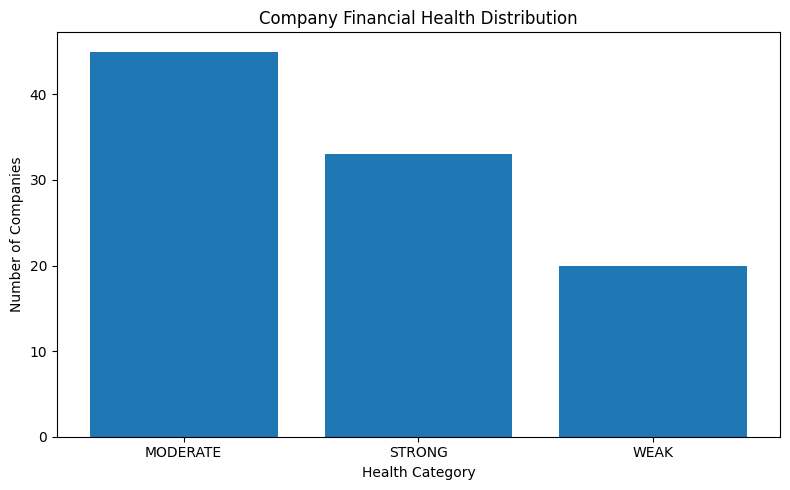

In [23]:
# Health Category Bar Chart
category_counts = score_df['health_category'].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.xlabel("Health Category")

plt.ylabel("Number of Companies")

plt.title("Company Financial Health Distribution")

plt.tight_layout()

plt.show()

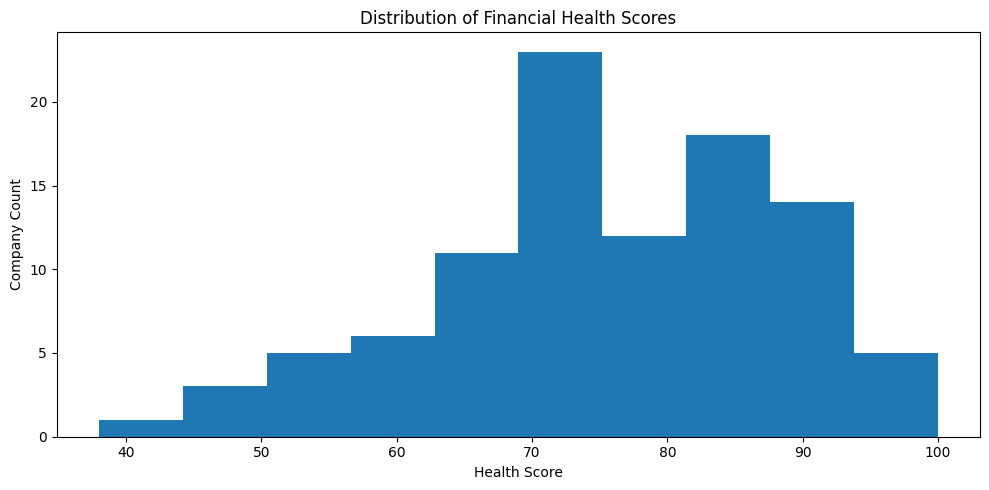

In [24]:
# Health Score Histogram
plt.figure(figsize=(10, 5))

plt.hist(
    score_df['health_score'],
    bins=10
)

plt.xlabel("Health Score")

plt.ylabel("Company Count")

plt.title("Distribution of Financial Health Scores")

plt.tight_layout()

plt.show()

In [25]:
# Weak Companies Table
score_df[[
    'company_name',
    'health_score',
    'health_category',
    'debt_to_equity',
    'free_cash_flow',
    'net_profit_margin_pct'
]].sort_values(
    by='health_score'
).head(20)

,company_name,health_score,health_category,debt_to_equity,free_cash_flow,net_profit_margin_pct
89,TVS Motor Company Ltd,38,WEAK,3.833432,-2254.0,4.544642
2,Adani Enterprises Ltd,48,WEAK,1.671358,-8455.0,3.458790
55,JSW Steel Ltd,48,WEAK,1.132807,-2389.0,5.127253
61,Mahindra & Mahindra Ltd,48,WEAK,1.641441,-11245.0,8.822387
71,Punjab National Bank,53,WEAK,3.684256,-29445.0,8.395911
12,Bajaj Finserv Ltd,54,WEAK,4.789368,-79634.0,14.128209
18,Bharat Heavy Electricals Limited,55,WEAK,0.362386,-2382.0,1.180262
75,SBI Life Insurance Company Ltd,55,WEAK,0.000000,-2099.0,1.434979
34,Grasim Industries Ltd,56,WEAK,1.547099,-33833.0,7.578372
46,IndusInd Bank Ltd,61,WEAK,6.885743,-17468.0,19.563697


<h2> Advanced Visual Insights </h2>

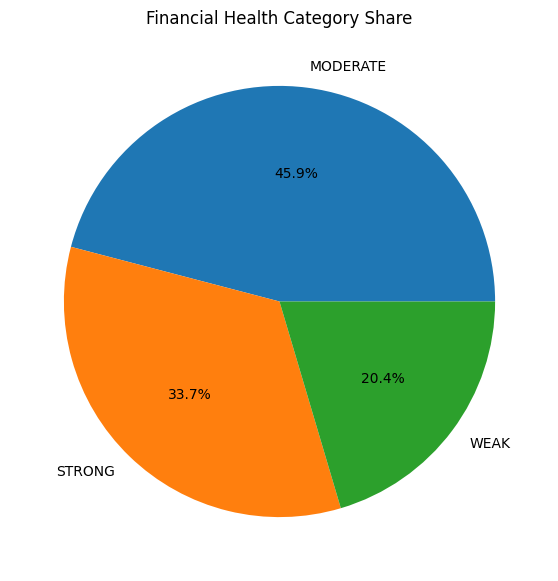

In [26]:
# Health Category Pie Chart
category_counts = score_df['health_category'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.1f%%'
)

plt.title("Financial Health Category Share")

plt.show()

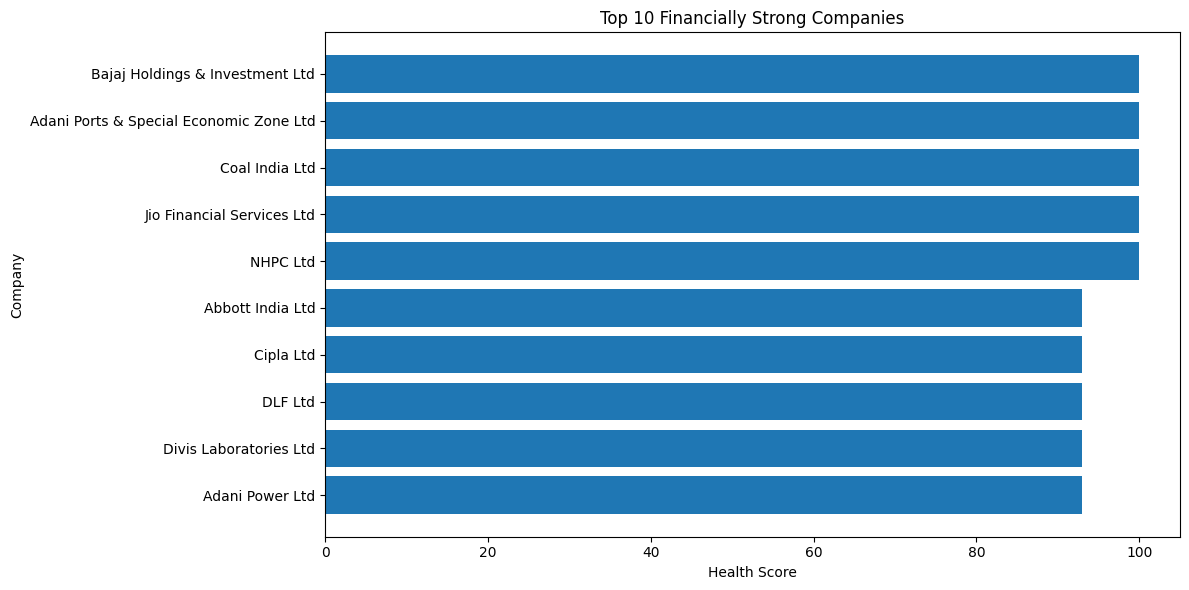

In [27]:
# Top 10 Strongest Companies Chart
top_companies = score_df.sort_values(
    by='health_score',
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_companies['company_name'],
    top_companies['health_score']
)

plt.xlabel("Health Score")

plt.ylabel("Company")

plt.title("Top 10 Financially Strong Companies")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

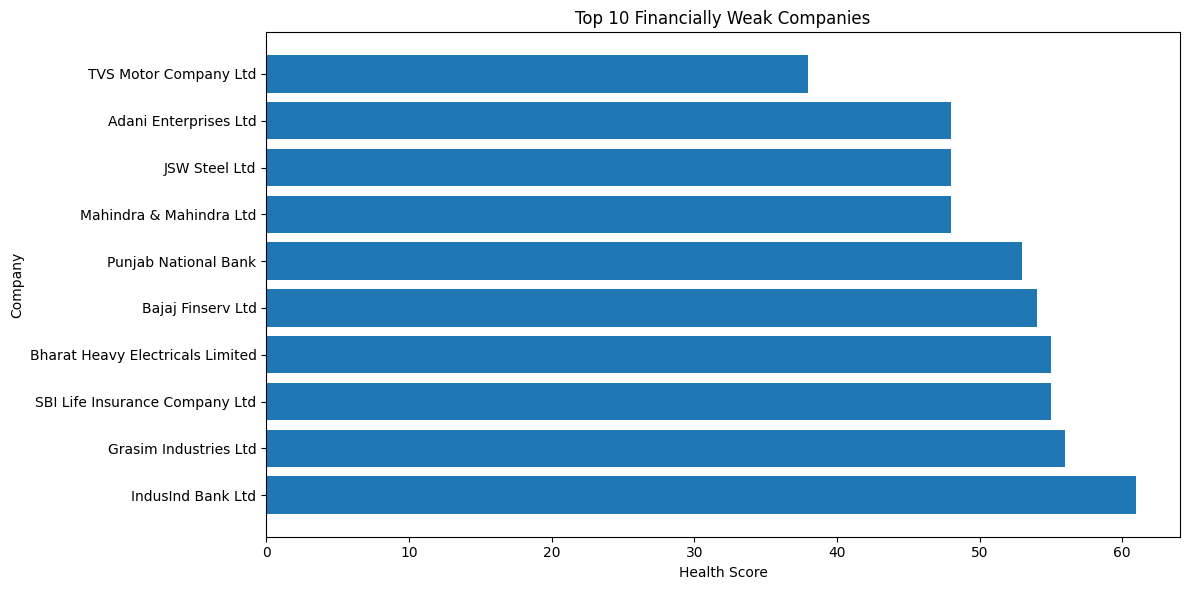

In [28]:
# Weakest Companies Chart
weak_companies = score_df.sort_values(
    by='health_score'
).head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    weak_companies['company_name'],
    weak_companies['health_score']
)

plt.xlabel("Health Score")

plt.ylabel("Company")

plt.title("Top 10 Financially Weak Companies")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

<h2> Final ML Dataset Export </h2>

In [29]:
# Save ML Output
score_df.to_csv(
    CLEAN_DIR / "company_health_scores.csv",
    index=False
)

print("Health scoring dataset saved successfully.")

Health scoring dataset saved successfully.


In [30]:
# Verify Saved File
pd.read_csv(
    CLEAN_DIR / "company_health_scores.csv"
).head()

,symbol,company_name,fiscal_year,net_profit_margin_pct,expense_ratio_pct,debt_to_equity,free_cash_flow,net_profit,profitability_score,expense_score,debt_score,cashflow_score,health_score,health_category
0,ABB,Abbott India Ltd,2024,20.533425,75.158147,0.022438,797.0,1201,25,18,25,25,93,STRONG
1,ADANIENSOL,Adani Energy Solutions Ltd,2024,7.201782,65.610887,2.932521,1095.0,1196,10,18,8,25,61,WEAK
2,ADANIENT,Adani Enterprises Ltd,2024,3.458790,88.200703,1.671358,-8455.0,3335,10,10,18,10,48,WEAK
3,ADANIGREEN,Adani Green Energy Ltd,2024,13.665944,20.629067,6.595282,-13347.0,1260,18,25,8,10,61,WEAK
4,ADANIPORTS,Adani Ports & Special Economic Zone Ltd,2024,30.339560,41.634533,0.937322,8250.0,8104,25,25,25,25,100,STRONG


<h2> Final ML Visual Analysis </h2>

In [31]:
# Health Score Statistics
score_df['health_score'].describe()

count     98.000000
mean      75.775510
std       13.606041
min       38.000000
25%       68.000000
50%       73.500000
75%       86.000000
max      100.000000
Name: health_score, dtype: float64

In [32]:
# Correlation Analysis
correlation_cols = [

    'net_profit_margin_pct',

    'expense_ratio_pct',

    'debt_to_equity',

    'free_cash_flow',

    'health_score'
]

score_df[correlation_cols].corr()

,net_profit_margin_pct,expense_ratio_pct,debt_to_equity,free_cash_flow,health_score
net_profit_margin_pct,1.000000,-0.277122,-0.024669,-0.030049,0.328322
expense_ratio_pct,-0.277122,1.000000,-0.283582,0.246226,-0.368432
debt_to_equity,-0.024669,-0.283582,1.000000,-0.294434,-0.304380
free_cash_flow,-0.030049,0.246226,-0.294434,1.000000,0.307118
health_score,0.328322,-0.368432,-0.304380,0.307118,1.000000


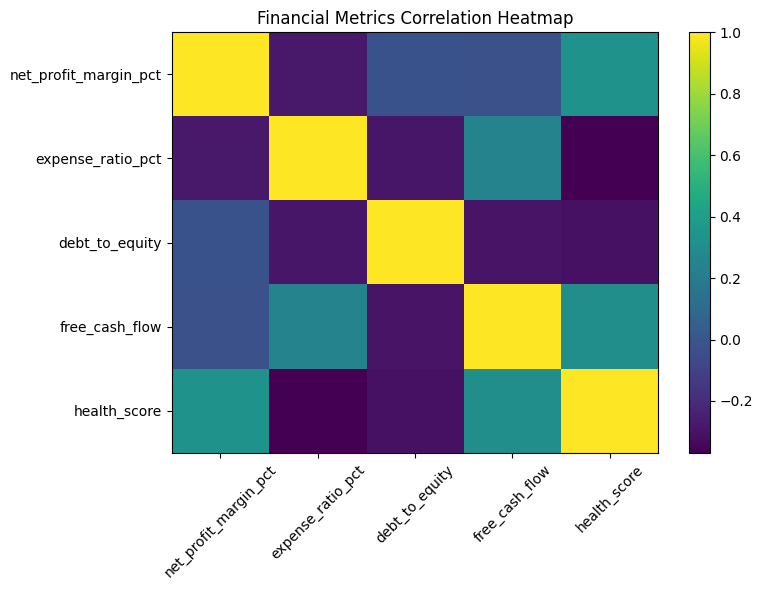

In [33]:
# Correlation Heatmap
corr_matrix = score_df[correlation_cols].corr()

plt.figure(figsize=(8, 6))

plt.imshow(
    corr_matrix,
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(correlation_cols)),
    correlation_cols,
    rotation=45
)

plt.yticks(
    range(len(correlation_cols)),
    correlation_cols
)

plt.title("Financial Metrics Correlation Heatmap")

plt.tight_layout()

plt.show()

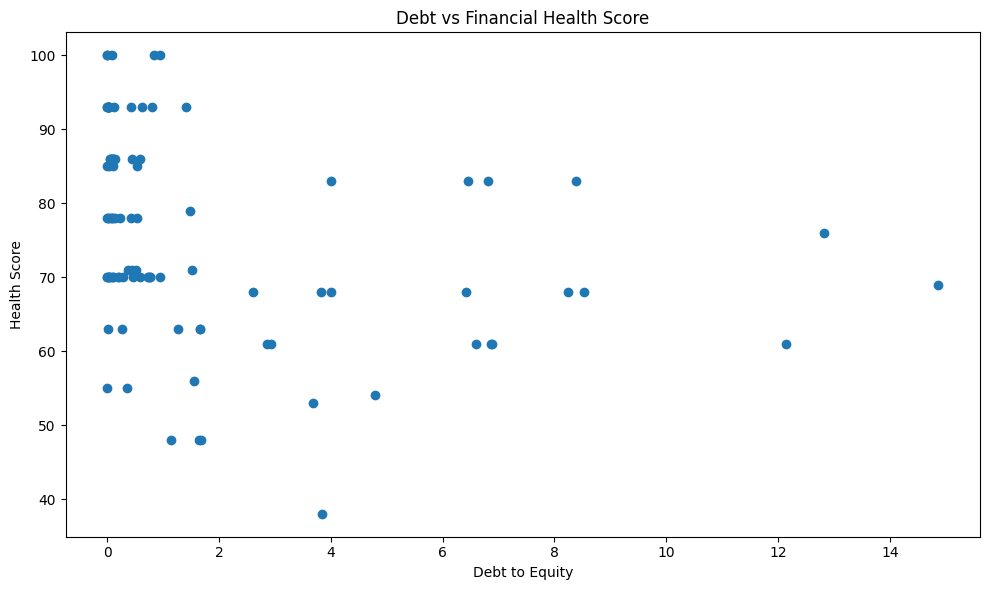

In [34]:
# Debt vs Health Score Scatter Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    score_df['debt_to_equity'],
    score_df['health_score']
)

plt.xlabel("Debt to Equity")

plt.ylabel("Health Score")

plt.title("Debt vs Financial Health Score")

plt.tight_layout()

plt.show()

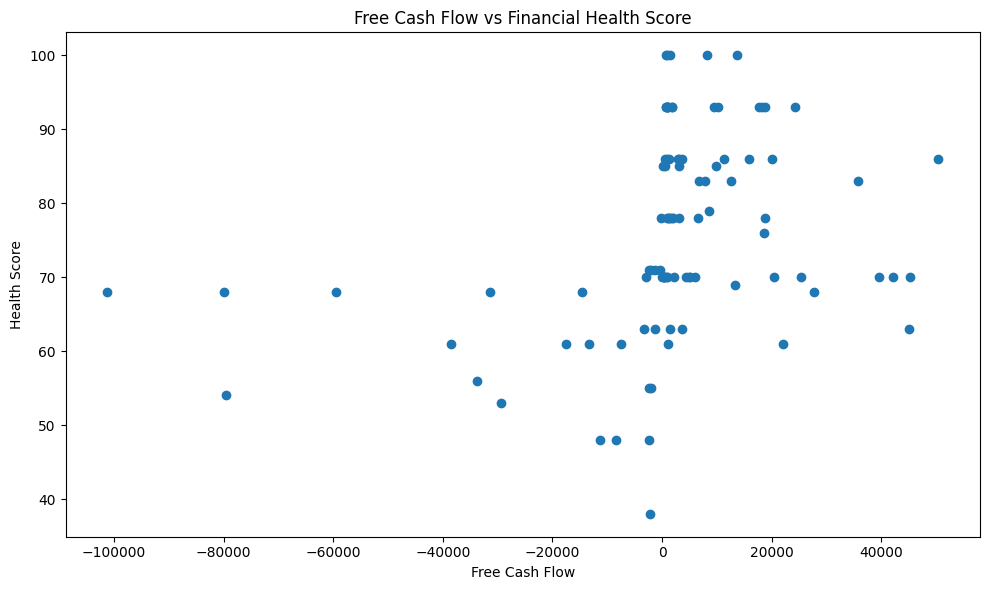

In [35]:
# Free Cash Flow vs Health Score
plt.figure(figsize=(10, 6))

plt.scatter(
    score_df['free_cash_flow'],
    score_df['health_score']
)

plt.xlabel("Free Cash Flow")

plt.ylabel("Health Score")

plt.title("Free Cash Flow vs Financial Health Score")

plt.tight_layout()

plt.show()

<h2> Final ML Insights Layer </h2>

In [36]:
# Top Strong Companies
score_df[[
    'company_name',
    'health_score',
    'health_category'
]].sort_values(
    by='health_score',
    ascending=False
).head(10)

,company_name,health_score,health_category
13,Bajaj Holdings & Investment Ltd,100,STRONG
4,Adani Ports & Special Economic Zone Ltd,100,STRONG
25,Coal India Ltd,100,STRONG
53,Jio Financial Services Ltd,100,STRONG
66,NHPC Ltd,100,STRONG
0,Abbott India Ltd,93,STRONG
24,Cipla Ltd,93,STRONG
28,DLF Ltd,93,STRONG
27,Divis Laboratories Ltd,93,STRONG
5,Adani Power Ltd,93,STRONG


In [37]:
# Top Weak Companies
score_df[[
    'company_name',
    'health_score',
    'health_category',
    'debt_to_equity',
    'free_cash_flow'
]].sort_values(
    by='health_score'
).head(10)

,company_name,health_score,health_category,debt_to_equity,free_cash_flow
89,TVS Motor Company Ltd,38,WEAK,3.833432,-2254.0
2,Adani Enterprises Ltd,48,WEAK,1.671358,-8455.0
55,JSW Steel Ltd,48,WEAK,1.132807,-2389.0
61,Mahindra & Mahindra Ltd,48,WEAK,1.641441,-11245.0
71,Punjab National Bank,53,WEAK,3.684256,-29445.0
12,Bajaj Finserv Ltd,54,WEAK,4.789368,-79634.0
18,Bharat Heavy Electricals Limited,55,WEAK,0.362386,-2382.0
75,SBI Life Insurance Company Ltd,55,WEAK,0.000000,-2099.0
34,Grasim Industries Ltd,56,WEAK,1.547099,-33833.0
46,IndusInd Bank Ltd,61,WEAK,6.885743,-17468.0


In [38]:
# Create Executive Summary Text
strong_count = (
    score_df['health_category'] == 'STRONG'
).sum()

moderate_count = (
    score_df['health_category'] == 'MODERATE'
).sum()

weak_count = (
    score_df['health_category'] == 'WEAK'
).sum()

avg_score = round(
    score_df['health_score'].mean(),
    2
)

print("NIFTY100 FINANCIAL HEALTH SUMMARY")
print("=" * 50)

print(f"Total Companies Analysed : {len(score_df)}")
print(f"Average Health Score     : {avg_score}")

print(f"Strong Companies         : {strong_count}")
print(f"Moderate Companies       : {moderate_count}")
print(f"Weak Companies           : {weak_count}")

NIFTY100 FINANCIAL HEALTH SUMMARY
Total Companies Analysed : 98
Average Health Score     : 75.78
Strong Companies         : 33
Moderate Companies       : 45
Weak Companies           : 20


<h2> Save Final ML Notebook Output </h2>

In [39]:
score_df.to_csv(
    CLEAN_DIR / "company_health_scores.csv",
    index=False
)

print("Final ML scoring dataset saved successfully.")

Final ML scoring dataset saved successfully.


In [40]:
# Final ML Folder Audit
list(CLEAN_DIR.glob("*"))

[WindowsPath('C:/Users/LENOVO/Desktop/nifty100_project/data/clean/analysis_clean.csv'),
 WindowsPath('C:/Users/LENOVO/Desktop/nifty100_project/data/clean/balancesheet_clean.csv'),
 WindowsPath('C:/Users/LENOVO/Desktop/nifty100_project/data/clean/cashflow_clean.csv'),
 WindowsPath('C:/Users/LENOVO/Desktop/nifty100_project/data/clean/companies_clean.csv'),
 WindowsPath('C:/Users/LENOVO/Desktop/nifty100_project/data/clean/company_health_scores.csv'),
 WindowsPath('C:/Users/LENOVO/Desktop/nifty100_project/data/clean/profit_clean.csv'),
 WindowsPath('C:/Users/LENOVO/Desktop/nifty100_project/data/clean/prosandcons.csv'),
 WindowsPath('C:/Users/LENOVO/Desktop/nifty100_project/data/clean/prosandcons_clean.csv')]